### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 90 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])         ### !!! ### !!! ### !!! ### affects bending strain
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.59619318, 0.1441305 , 0.42094368, 0.59001657, 0.99762586,
       0.78822368, 0.87658446, 0.58813331, 0.05369407, 0.82409216,
       0.73912047, 0.44166936, 0.81854754, 0.02646714, 0.82100476,
       0.78959229, 0.39402533, 0.54269566, 0.64103183, 0.40395112])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 10)

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.78089702,  0.        ,  0.51689293],
        [ 0.        ,  1.        , -0.56149649],
        [-0.62465978,  0.        ,  0.64617598]],

       [[ 0.99947237,  0.        ,  0.03214358],
        [ 0.        ,  1.        , -0.143632  ],
        [-0.03248036,  0.        ,  0.98910901]],

       [[ 0.99499183,  0.        ,  0.09123047],
        [ 0.        ,  1.        , -0.40862193],
        [-0.09995628,  0.        ,  0.90813276]],

       [[ 0.97600256,  0.        ,  0.18094286],
        [ 0.        ,  1.        , -0.55637479],
        [-0.21775906,  0.        ,  0.81099123]],

       [[ 0.84239613,  0.        ,  0.29222233],
        [ 0.        ,  1.        , -0.84018586],
        [-0.53885876,  0.        ,  0.4568302 ]],

       [[ 0.69799863,  0.        ,  0.50492578],
        [ 0.        ,  1.        , -0.7091019 ],
        [-0.7160991 ,  0.        ,  0.49216303]],

       [[ 0.63566401,  0.        ,  0.49388824],
        [ 0.        ,  1.        , -0.76855817],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-3.93019719e-01,  0.00000000e+00,  3.65410780e-01],
        [ 0.00000000e+00,  0.00000000e+00, -9.70728979e-02],
        [-4.91320134e-01,  0.00000000e+00, -3.76653337e-01]],

       [[-1.69900228e-02,  0.00000000e+00,  5.14243225e-01],
        [ 0.00000000e+00,  0.00000000e+00, -6.67323694e-01],
        [-5.22809984e-01,  0.00000000e+00, -1.13616048e-01]],

       [[-4.16944685e-02,  0.00000000e+00,  3.73940499e-01],
        [ 0.00000000e+00,  0.00000000e+00, -1.08740681e-01],
        [-4.15038010e-01,  0.00000000e+00, -8.64946161e-02]],

       [[-1.22332544e-01,  0.00000000e+00,  3.40674224e-01],
        [ 0.00000000e+00,  0.00000000e+00, -7.88191699e-01],
        [-5.48298076e-01,  0.00000000e+00, -6.16742257e-01]],

       [[-3.33736706e-01,  0.00000000e+00,  1.97109622e-01],
        [ 0.00000000e+00,  0.00000000e+00, -1.02800327e-01],
        [-5.21729496e-01,  0.00000000e+00, -3.15152573e-01]],

       [[-4.80740862e-01,  0.00000000e+00, -6.75809096e-02],
        [ 0.00

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.40365059,  0.29020507,  0.31680917],
       [ 0.68605418,  0.4690427 ,  0.3502622 ],
       [ 0.17625406,  0.15864594,  0.56254671],
       [ 1.02325303,  0.26212731,  0.2302248 ],
       [ 0.3660255 ,  0.02608672,  0.2204184 ],
       [ 0.59109771,  0.60949792, -0.5183363 ],
       [ 0.41042302, -0.29099579,  0.00230253],
       [ 0.883299  ,  0.37299385,  0.02936055],
       [ 0.68584613,  0.2770132 ,  0.48139576],
       [ 0.96305483, -0.53320889, -0.27943776],
       [ 0.18030932,  0.60479401,  0.37968855],
       [ 0.67018078, -0.2883195 ,  0.64654847],
       [ 0.52869094,  0.26334377, -0.51906625],
       [ 0.54659844,  0.6418319 , -0.23165002],
       [ 0.41790651,  0.0995279 , -0.09765501],
       [ 0.3946481 ,  0.14544952,  0.11592923],
       [ 0.85508855, -0.03301067,  0.25916597],
       [ 0.51078718,  0.52487406,  0.01602329],
       [ 1.05093777,  0.1875232 ,  0.14669913],
       [ 1.12513163, -0.20063772,  0.13926047]])

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.98639651, -0.03396715, -0.34343729],
       [ 0.40480349,  0.21088748,  0.5130353 ],
       [ 0.98617213,  0.27030151,  0.48283843],
       [ 0.78938308, -0.16667283, -0.98116163],
       [ 0.23391962,  0.24366596, -0.13521036],
       [ 0.4756201 , -0.26349054, -0.52461636],
       [ 0.94173517, -0.58706682, -0.39430508],
       [ 0.53977167,  0.30829128, -0.73818363],
       [ 0.30156062,  0.0260612 , -0.22268292],
       [-0.25245967, -0.35895351, -0.53471337],
       [ 0.80484081,  0.76264038, -0.2033411 ],
       [ 0.14346311,  0.26870636, -0.18358156],
       [ 0.39926486,  0.16190318, -0.06609392],
       [ 0.76880424,  0.02020751, -0.47067552],
       [ 0.59223001, -0.56108472, -0.37247205],
       [ 0.12195137,  0.14454609, -0.22079907],
       [ 0.50894739, -0.54560988,  0.10170791],
       [ 0.9740706 ,  0.16816966, -0.19684852],
       [ 0.55323887, -0.62217434, -0.37402606],
       [ 0.14019385, -0.09515233, -0.17861803]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.26643518, 0.05981638, 0.52383932],
       [0.0588382 , 0.42323928, 0.17877401],
       [0.06186296, 0.74502521, 0.98954771],
       [0.29805509, 0.92970617, 0.05974413],
       [0.50422871, 0.85260054, 0.86427361],
       [0.9984963 , 0.07217004, 0.71675315],
       [0.79678356, 0.13995824, 0.37280177],
       [0.3192921 , 0.27716061, 0.90845204],
       [0.89537812, 0.44122899, 0.92577503],
       [0.29688394, 0.17549836, 0.40250597],
       [0.79036595, 0.97743276, 0.04105022],
       [0.36681603, 0.72781967, 0.58211405],
       [0.57052822, 0.77431617, 0.32433773],
       [0.75299085, 0.71674324, 0.27776969],
       [0.93565077, 0.5392265 , 0.51748069],
       [0.38501837, 0.40457837, 0.98427151],
       [0.55920268, 0.94451928, 0.44982145],
       [0.64657035, 0.2979497 , 0.80533976],
       [0.84174352, 0.40672833, 0.95688868],
       [0.92766728, 0.90553849, 0.46060375]])

In [44]:
theta(φ,θ,ψ)

array([[0.59619318, 0.67469578, 0.64198279],
       [0.1441305 , 0.03248608, 0.39850676],
       [0.42094368, 0.10012348, 0.1084764 ],
       [0.59001657, 0.21951784, 0.55311384],
       [0.99762586, 0.56908177, 0.07689879],
       [0.78822368, 0.79819748, 0.2611356 ],
       [0.87658446, 0.88192796, 0.40494306],
       [0.58813331, 0.3228286 , 0.98863536],
       [0.05369407, 0.27860386, 0.7844499 ],
       [0.82409216, 0.86624636, 0.63485801],
       [0.73912047, 0.25783133, 0.03673342],
       [0.44166936, 0.01855116, 0.15005075],
       [0.81854754, 0.81694126, 0.20790839],
       [0.02646714, 0.60251488, 0.99895548],
       [0.82100476, 0.95720826, 0.14861108],
       [0.78959229, 0.37577022, 0.38138837],
       [0.39402533, 0.82257241, 0.06853467],
       [0.54269566, 0.4782439 , 0.29244574],
       [0.64103183, 0.4048697 , 0.91603272],
       [0.40395112, 0.76970722, 0.94237058]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.29616921, -0.07810741,  0.48852448],
       [ 0.12694481,  0.4127266 ,  0.13855172],
       [ 0.71509408,  0.68384789,  0.68405372],
       [ 0.22402812,  0.91216161, -0.2047188 ],
       [ 0.90159629,  0.43504205,  0.1182561 ],
       [ 1.02388701, -0.53037393,  0.31516042],
       [ 0.82534556, -0.12663658,  0.1468915 ],
       [ 0.54311901, -0.00799751,  0.74225275],
       [ 1.05680975, -0.28128801,  0.14100966],
       [ 0.35952635,  0.0577485 ,  0.32714967],
       [ 0.46588065,  0.94826202, -0.63911481],
       [ 0.63536007,  0.51904732,  0.16168628],
       [ 0.59873678,  0.59914893, -0.20378447],
       [ 0.70085989,  0.52679764, -0.34185859],
       [ 0.96053319,  0.12266212, -0.21697635],
       [ 0.71301134,  0.03490945,  0.68701476],
       [ 0.63670508,  0.70588427, -0.22957995],
       [ 0.80677944, -0.1872293 ,  0.42465707],
       [ 1.02525135, -0.30692473,  0.25244227],
       [ 0.78993601,  0.53695269, -0.55934605]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.83544858, -0.18667453,  0.51689293],
        [ 0.4954818 ,  0.66273636, -0.56149649],
        [-0.23774664,  0.72521248,  0.64617598]],

       [[ 0.92296548, -0.38353814,  0.03214358],
        [ 0.38401899,  0.91208512, -0.143632  ],
        [ 0.02577067,  0.14491113,  0.98910901]],

       [[ 0.99356543, -0.06711733,  0.09123047],
        [ 0.09881276,  0.90733905, -0.40862193],
        [-0.05535136,  0.41500736,  0.90813276]],

       [[ 0.8941214 , -0.40964204,  0.18094286],
        [ 0.43652096,  0.70703362, -0.55637479],
        [ 0.09998182,  0.57645196,  0.81099123]],

       [[ 0.8746876 ,  0.38668813,  0.29222233],
        [ 0.04166101,  0.54069592, -0.84018586],
        [-0.48289332,  0.74707443,  0.4568302 ]],

       [[ 0.80543407,  0.31036417,  0.50492578],
        [ 0.18204273,  0.6812011 , -0.7091019 ],
        [-0.56403582,  0.66305289,  0.49216303]],

       [[ 0.81799511,  0.29488709,  0.49388824],
        [ 0.2520518 ,  0.58803761, -0.76855817],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[ 0.16206609, -0.40640934, -0.03602282],
       [-0.1692705 , -0.00512658,  0.06784734],
       [ 0.01316892, -0.4207594 ,  0.31596425],
       [-0.30285941,  0.05502073,  0.65471994],
       [ 0.86439118, -0.99910337,  0.48131195],
       [ 0.47084884, -0.92411888, -0.56288156],
       [ 0.28441996, -0.69024948, -0.34875113],
       [-0.36949522, -0.55426396,  0.29896685],
       [-0.10683134,  0.41387527, -0.09393138],
       [ 0.22230127, -0.45056992,  0.03248797],
       [ 0.16812069, -0.15783006,  0.52110313],
       [-0.11928738, -0.21177715,  0.33995417],
       [ 0.60252524, -0.50030223,  0.13453403],
       [-0.41894282,  0.44498516, -0.01252838],
       [ 0.76956334, -0.86096777, -0.49429069],
       [ 0.11947567, -0.83533618,  0.29662407],
       [ 0.59026907, -0.27885759, -0.14826701],
       [ 0.271689  , -0.49857082, -0.03367153],
       [-0.30854737, -0.48504294,  0.4775879 ],
       [-0.12499778, -0.09490602,  0.43833208]])

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[ 1.73108986e-01, -4.86630157e-01,  3.50665035e-01],
       [-2.25167841e-02, -6.37462031e-03,  8.66344609e-03],
       [ 4.02257801e-04, -2.27513301e-02,  1.94384623e-02],
       [-1.19061371e-01, -1.85013769e-01,  2.00432529e-01],
       [ 3.24728310e-01, -5.67610336e-01, -1.22325277e-02],
       [ 5.08037055e-01, -5.21709520e-01,  6.11957375e-02],
       [ 6.82658316e-01, -7.55445955e-01,  1.67532785e-01],
       [-4.14692147e-01, -4.60366749e-01,  3.97025877e-01],
       [-2.01812948e-02, -1.69840176e-01,  6.17015123e-02],
       [ 5.56098671e-01, -8.34704600e-01,  4.17074783e-01],
       [ 5.03856875e-02, -1.46402309e-01,  1.37751690e-02],
       [-9.20457601e-03, -1.03546688e-02,  2.83735360e-02],
       [ 5.46376522e-01, -5.46906998e-01, -2.13683940e-03],
       [ 8.87864456e-02, -5.65739583e-01,  3.38870549e-01],
       [ 7.12788439e-01, -5.85775979e-01, -1.64813395e-01],
       [ 5.50463276e-02, -3.49269580e-01,  2.30161590e-01],
       [ 2.56699529e-01, -1.18373307e-01

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
    t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[ 1.62066085e+08, -4.06409339e+08, -3.60228222e+07],
       [-1.69270498e+08, -5.12657565e+06,  6.78473365e+07],
       [ 1.31689232e+07, -4.20759405e+08,  3.15964246e+08],
       [-3.02859406e+08,  5.50207310e+07,  6.54719937e+08],
       [ 8.64391183e+08, -9.99103369e+08,  4.81311951e+08],
       [ 4.70848844e+08, -9.24118878e+08, -5.62881564e+08],
       [ 2.84419955e+08, -6.90249482e+08, -3.48751134e+08],
       [-3.69495221e+08, -5.54263960e+08,  2.98966846e+08],
       [-1.06831337e+08,  4.13875274e+08, -9.39313805e+07],
       [ 2.22301273e+08, -4.50569924e+08,  3.24879720e+07],
       [ 1.68120687e+08, -1.57830055e+08,  5.21103128e+08],
       [-1.19287384e+08, -2.11777149e+08,  3.39954168e+08],
       [ 6.02525238e+08, -5.00302233e+08,  1.34534029e+08],
       [-4.18942817e+08,  4.44985165e+08, -1.25283753e+07],
       [ 7.69563336e+08, -8.60967771e+08, -4.94290695e+08],
       [ 1.19475670e+08, -8.35336179e+08,  2.96624071e+08],
       [ 5.90269072e+08, -2.78857587e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[ 5.91897805e+06,  3.55988519e+07, -3.74996723e+08],
       [ 3.17351457e+05, -7.65711532e+07, -4.99399958e+06],
       [ 4.13756225e+07, -1.34720755e+08, -1.81127762e+08],
       [-7.53714182e+07, -5.39493155e+08,  1.04722102e+07],
       [-2.59190592e+08, -8.49621666e+08, -1.29815560e+09],
       [-7.47907381e+08,  1.78649111e+08, -9.18922158e+08],
       [-5.52448170e+08,  1.18452211e+08, -6.84983754e+08],
       [ 2.61456994e+08, -4.64039152e+08, -5.37160125e+08],
       [-3.27799202e+08, -5.37946221e+07,  1.35790223e+08],
       [-1.44057848e+08, -1.05505686e+08, -4.77513524e+08],
       [ 9.58598888e+07, -4.03305334e+08, -1.53078592e+08],
       [ 1.14901090e+07, -1.66178389e+08, -9.94903532e+07],
       [-1.60434056e+08, -3.90288747e+08, -7.32876021e+08],
       [-3.66660675e+08, -3.31043921e+08,  5.02876271e+08],
       [-9.47091888e+08, -1.97088005e+08, -1.13123872e+09],
       [-2.24732401e+06, -2.51877976e+08, -7.08419531e+08],
       [-1.86582050e+08, -9.84222592e+07

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 7974018.42782954,  3142247.00445672,   424159.50831732],
       [ 1568638.89189633,  -247522.45908642,  3894852.14023335],
       [ 4287318.72464252,   557976.43355932,   564350.12285551],
       [ 6759396.81097867,  -882207.54028123,  3200890.16550369],
       [ 8628677.02643412,  5044724.93232324, -5024497.44084393],
       [ 6820331.42322106,  6130257.29070961, -4359249.75724922],
       [ 7572098.05783332,  5707056.60940879, -5120089.6611334 ],
       [ 8186969.94922522, -2256751.41678818,  5934471.7099126 ],
       [ 2670471.36195672,  2365037.90201934,  7383482.27676377],
       [ 8622977.0907778 ,  4003040.97593413, -3485872.18691386],
       [ 7216113.80780819,  2330862.96996338, -1622131.45946818],
       [ 4441097.16354234,  -455879.20254564,  1274354.32222905],
       [ 6638282.26393282,  6651360.8415288 , -4995330.36219436],
       [ 5877327.01258185,  5760784.72497352,  8077647.89969287],
       [ 5555407.11167442,  8484500.77538081, -6129276.00211968],
       [ 8

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[-1.16415322e-10,  3.53596977e-10, -4.65661287e-10],
       [-4.36557457e-11, -1.22957229e-10,  0.00000000e+00],
       [ 3.63797881e-12, -1.45558808e-11, -2.91038305e-11],
       [ 5.82076609e-11, -1.89684962e-10, -2.32830644e-10],
       [ 0.00000000e+00,  6.53851428e-10,  9.31322575e-10],
       [ 1.86264515e-09, -2.31766299e-10,  1.86264515e-09],
       [ 4.65661287e-10, -6.00944882e-10,  0.00000000e+00],
       [ 0.00000000e+00,  4.97813040e-10,  4.65661287e-10],
       [ 4.65661287e-10, -4.97278965e-10,  0.00000000e+00],
       [ 0.00000000e+00,  3.39187704e-10,  4.65661287e-10],
       [ 5.82076609e-11, -2.33307327e-10,  0.00000000e+00],
       [ 1.45519152e-11,  1.48470005e-10, -2.91038305e-11],
       [-4.65661287e-10,  1.25120613e-10,  0.00000000e+00],
       [ 0.00000000e+00,  7.79814170e-10, -9.31322575e-10],
       [-9.31322575e-10,  1.66688566e-10, -9.31322575e-10],
       [ 7.27595761e-12, -8.98851491e-11,  0.00000000e+00],
       [ 2.32830644e-10, -7.23366413e-11

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[2.66998590e+01, 3.83787357e-01, 1.09603741e+02],
       [2.92117796e+01, 2.83100632e+00, 3.29239266e+00],
       [1.32070652e+02, 6.76460149e+01, 8.13096519e+01],
       [3.92243716e+01, 7.61263009e-02, 1.89639648e-01],
       [4.06996246e+00, 8.45724093e+01, 1.70670874e+02],
       [2.47583274e+01, 2.40216026e+01, 2.28205996e+01],
       [6.40209503e+01, 2.11336778e+02, 2.38222316e+02],
       [7.80407279e+01, 8.08713597e+01, 7.25435809e+01],
       [1.35365359e+02, 1.28590893e+02, 7.66088373e+01],
       [2.22927656e+01, 1.89112940e+02, 1.41942586e+02],
       [3.78723646e+01, 1.14855388e+02, 9.37060157e+01],
       [1.59845804e+02, 1.08575510e+02, 2.06761100e+02],
       [1.95071896e+02, 6.49210358e+00, 1.70420447e+02],
       [6.89945262e+01, 5.05307037e+01, 1.84403171e+02],
       [1.58431821e+02, 9.86051574e+00, 6.71472661e+01],
       [1.50402458e+02, 3.23170558e+00, 1.23560051e+01],
       [1.41567044e+01, 7.15812047e+00, 2.48960606e+01],
       [4.71683213e+01, 8.04919

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = np.sum(phi(x,y,z) * e3, axis=1)+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        if k[i]<0:
            k0[i]=0
        elif 0<=k[i]<=d0/20:
            k0[i]=(fg_e2*10*k[i]**2)/((d0/8-d0/40)*(d0))
        else:
            k0[i]=(fg_e2*(k[i]-d0/40))/(d0/8-d0/40)
            
    result = k0[:, np.newaxis] * e3 
    
    return result        

In [63]:
sigma(x,y,z)

array([[    0.        ,     0.        , 19047.62144233],
       [    0.        ,     0.        ,  8990.92409826],
       [    0.        ,     0.        , 32620.38037027],
       [    0.        ,     0.        ,  5521.87799978],
       [    0.        ,     0.        , 28969.35059847],
       [    0.        ,     0.        , 24669.9656082 ],
       [    0.        ,     0.        , 14645.73317772],
       [    0.        ,     0.        , 30256.90142219],
       [    0.        ,     0.        , 30761.7684175 ],
       [    0.        ,     0.        , 15511.44221358],
       [    0.        ,     0.        ,  4977.05660402],
       [    0.        ,     0.        , 20745.99947823],
       [    0.        ,     0.        , 13233.28121762],
       [    0.        ,     0.        , 11876.08684734],
       [    0.        ,     0.        , 18862.30341177],
       [    0.        ,     0.        , 32466.60918958],
       [    0.        ,     0.        , 16890.42029164],
       [    0.        ,     0. 

In [64]:
def ne_hat(x,y,z,dx,dy,dz, flag):
    ans = fg_e.T - fD(dx,dy,dz)  #- sigma(x,y,z).T
    if flag:  
        ans[:, :] = 0                                       ### !!! ### !!! ### !!! ###
    return ans

In [65]:
ne_hat(x,y,z,dx,dy,dz, False).T

array([[-2.66998590e+01, -3.83787357e-01, -2.87579469e+02],
       [-2.92117796e+01, -2.83100632e+00, -1.81268121e+02],
       [-1.32070652e+02, -6.76460149e+01, -2.59285380e+02],
       [-3.92243716e+01, -7.61263009e-02, -1.78165368e+02],
       [-4.06996246e+00, -8.45724093e+01, -3.48646602e+02],
       [-2.47583274e+01, -2.40216026e+01, -2.00796328e+02],
       [-6.40209503e+01, -2.11336778e+02, -4.16198044e+02],
       [-7.80407279e+01, -8.08713597e+01, -2.50519309e+02],
       [-1.35365359e+02, -1.28590893e+02, -2.54584566e+02],
       [-2.22927656e+01, -1.89112940e+02, -3.19918314e+02],
       [-3.78723646e+01, -1.14855388e+02, -2.71681744e+02],
       [-1.59845804e+02, -1.08575510e+02, -3.84736828e+02],
       [-1.95071896e+02, -6.49210358e+00, -3.48396176e+02],
       [-6.89945262e+01, -5.05307037e+01, -3.62378899e+02],
       [-1.58431821e+02, -9.86051574e+00, -2.45122994e+02],
       [-1.50402458e+02, -3.23170558e+00, -1.90331733e+02],
       [-1.41567044e+01, -7.15812047e+00

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', Ret, Jrho0, Ret)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[126.71782974, -29.02335635,  33.40037925],
        [-29.02335635, 131.52783073, -36.28255433],
        [ 33.40037925, -36.28255433, 141.75433953]],

       [[100.10332098,  -0.46168468,   3.1793505 ],
        [ -0.46168468, 102.0630152 , -14.20677077],
        [  3.1793505 , -14.20677077, 197.83366382]],

       [[100.83229988,  -3.72787711,   8.28493794],
        [ -3.72787711, 116.69718833, -37.10829647],
        [  8.28493794, -37.10829647, 182.47051179]],

       [[103.27403173, -10.06720444,  14.67430694],
        [-10.06720444, 130.95529107, -45.12150769],
        [ 14.67430694, -45.12150769, 165.7706772 ]],

       [[108.53938875, -24.55210659,  13.34959838],
        [-24.55210659, 170.59122795, -38.38222758],
        [ 13.34959838, -38.38222758, 120.8693833 ]],

       [[125.49500468, -35.80438309,  24.8505806 ],
        [-35.80438309, 150.28255003, -34.89937417],
        [ 24.8505806 , -34.89937417, 124.22244529]],

       [[124.39255963, -37.95818439,  20.08569729],


### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 20.47601006945673,
 40.959214573408026,
 61.456810473883436,
 81.97599978887138,
 102.52399212252116,
 123.10800719801298,
 143.7352773939863,
 164.41305028541942,
 185.14859118985243,
 205.94918571985045,
 226.822142342603,
 247.77479494756105,
 268.8145054230128,
 289.948666242506,
 311.18470306202374,
 332.53007732882884,
 353.992288902892,
 375.5788786918262,
 397.2974313002532]

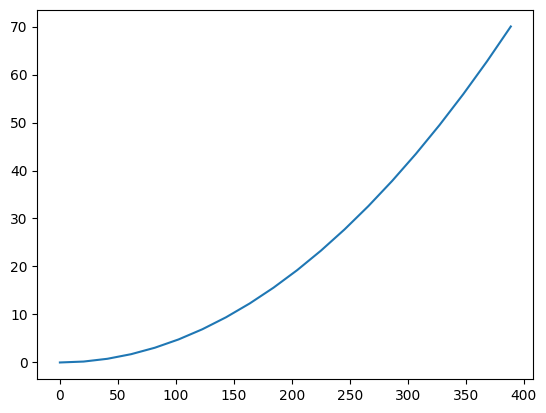

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)
    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz, False).T
    Z = (Z1 + Z2 )


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T)
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    # D[:, :] = 0                                                     ### !!! ### !!! ### !!! ###

    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='lm')

In [83]:
root_

 message: The relative error between two consecutive iterates is at most 0.000000
 success: True
  status: 2
     fun: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
       x: [ 0.000e+00  2.048e+01 ...  0.000e+00  0.000e+00]
   cov_x: None
  method: lm
    nfev: 251
    fjac: [[-1.406e+02  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00 -1.330e+02 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ... -0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00 -0.000e+00]]
    ipvt: [180 179 ...  94  95]
     qtf: [-7.523e-01 -7.131e-01 ...  5.712e-05 -7.298e-05]

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
q0 = root_.x                                            # start from static solution

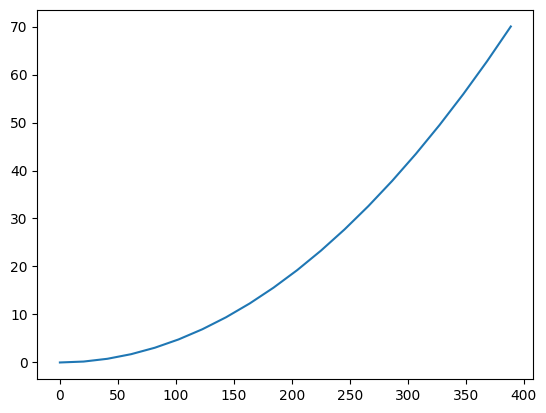

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [87]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [88]:
Number*sampleTime

600.0

In [89]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [90]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [91]:
simData.shape 

(60001, 24)

In [92]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

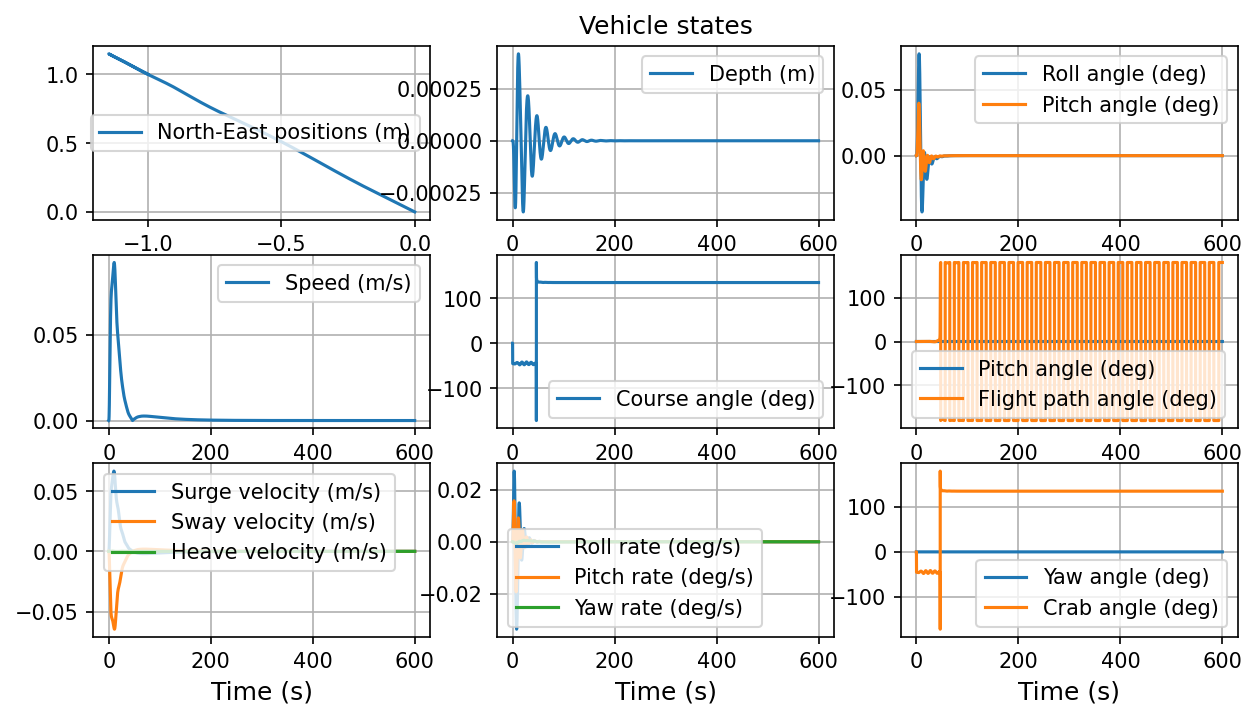

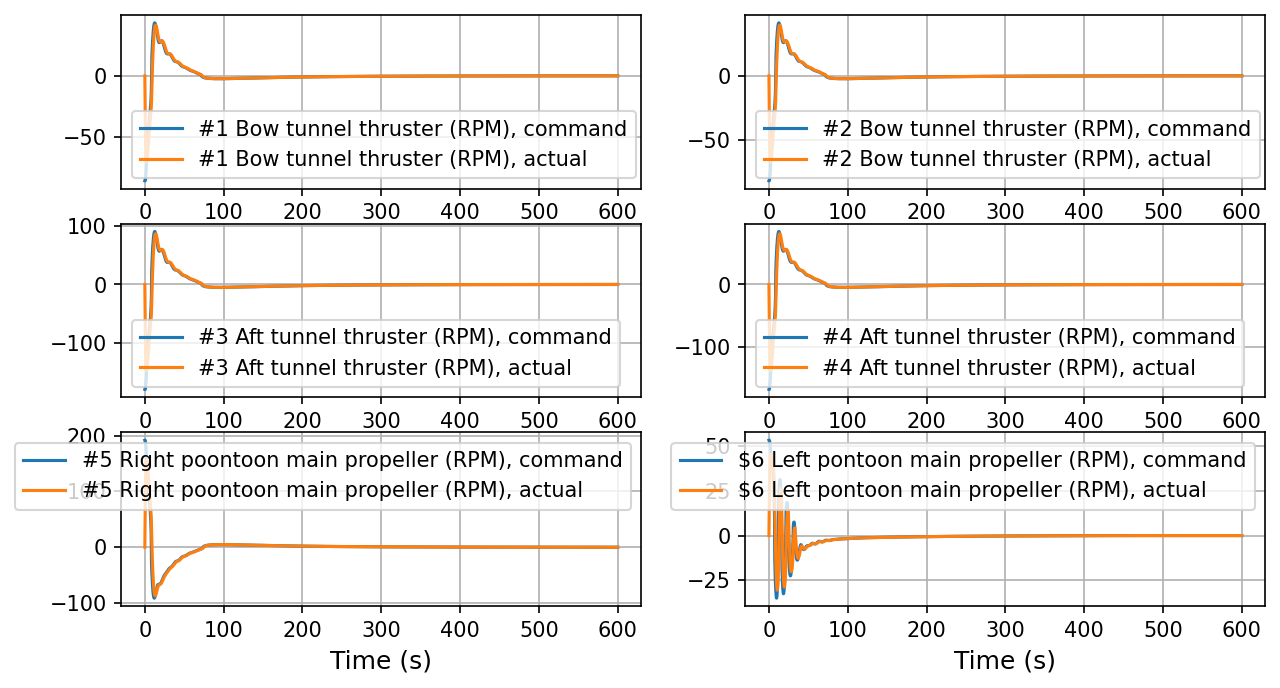

In [93]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [94]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

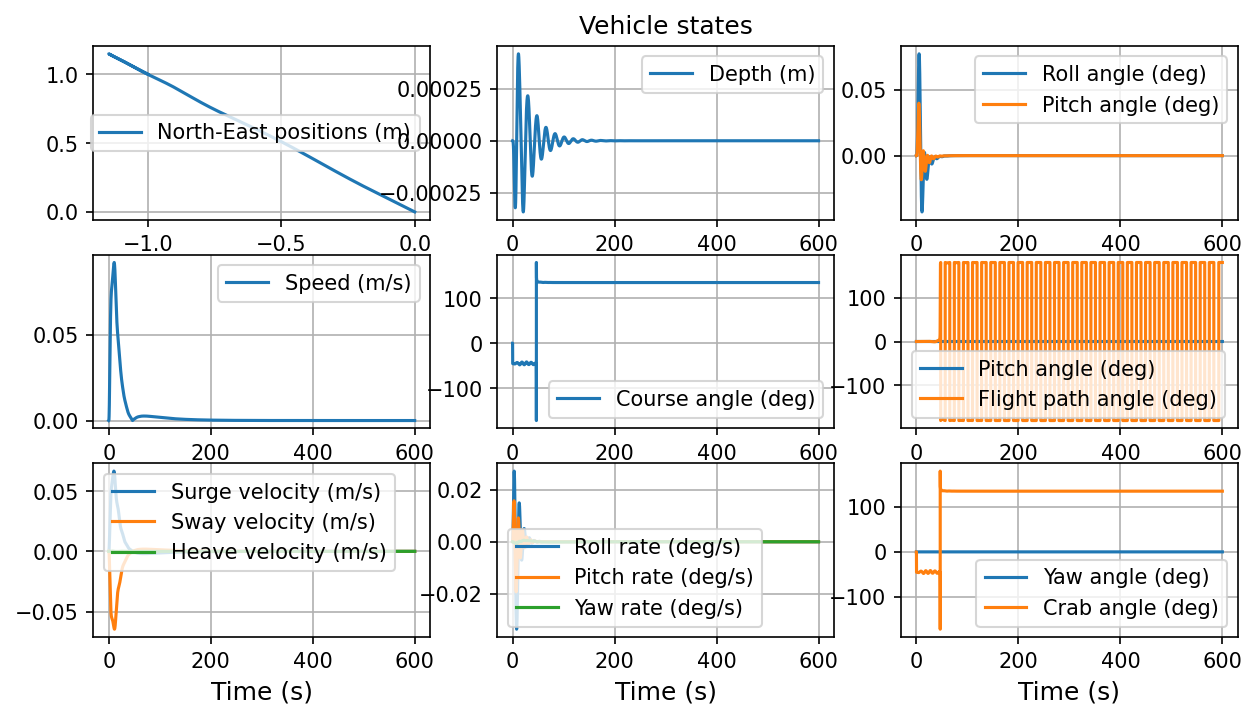

In [95]:
plotVehicleStates(simTime, simData, 3)

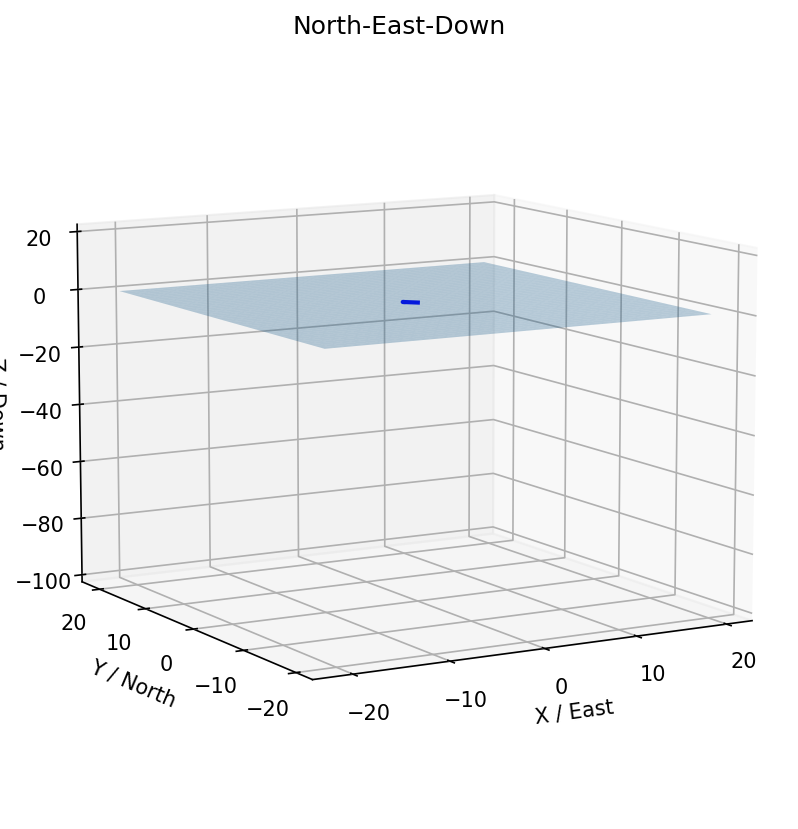

In [96]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [97]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [98]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [99]:
def dynamic_func(t, Q, T):
    
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = simData[:, 3][idx]
    theta_ve = simData[:, 4][idx]
    psi_ve = simData[:, 5][idx]
    
    RET = Ret(φ,θ,ψ)
    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    x_n=x.copy()
    y_n=y.copy()
    z_n=z.copy()
    x_n[-1]-=x_ve
    y_n[-1]-=y_ve
    z_n[-1]-=z_ve

    Z2 = ne_hat(x_n, y_n, z_n, dx, dy, dz, False).T
    
    Z = (Z1 + Z2)

############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ).T
    C = C1

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    φ_n=φ.copy()
    θ_n=θ.copy()
    ψ_n=ψ.copy()
  
    φ_n[-1]-= phi_ve
    θ_n[-1]-= theta_ve
    ψ_n[-1]-= psi_ve

    D = w_e(φ_n,θ_n,ψ_n,dφ,dθ,dψ)                                              
#     D[:, :] = 0                                                     ### !!! ### !!! ### !!! ###
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################


    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         

    ans=np.concatenate([dx, ddx, 
                            dy, ddy, 
                            dz, ddz, 
                            dφ, ddφ, 
                            dθ, ddθ,  
                            dψ, ddψ, 
                           ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
 
    return ans

In [100]:
T_ = MyTime()

# initial conditions - to control dynamics
# q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.0001 for i in range(N)]),
#                                           np.array([0.000003 for i in range(N)]),
#                                           np.array([0.000019*i/N for i in range(N)]))

q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.00003 for i in range(N)]),
                                          np.array([0.001267*i/N for i in range(N)]))

In [101]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(T_, ), 
               )
print(datetime.now() - startTime1)

Physical time:  6.591676239077574e-10  Iteration wall-clock time:  0:00:00.015751
Physical time:  1.0003637211162737  Iteration wall-clock time:  0:00:03.051240
Physical time:  2.001780222428539  Iteration wall-clock time:  0:00:01.488798
Physical time:  3.0013487352601365  Iteration wall-clock time:  0:00:01.424582
Physical time:  4.001050704405696  Iteration wall-clock time:  0:00:01.440554
Physical time:  5.000253543014122  Iteration wall-clock time:  0:00:01.429744
Physical time:  6.008903869633731  Iteration wall-clock time:  0:00:01.453329
Physical time:  7.0006539964020345  Iteration wall-clock time:  0:00:01.432559
Physical time:  8.004325459659633  Iteration wall-clock time:  0:00:01.483962
Physical time:  9.004380860351954  Iteration wall-clock time:  0:00:01.510050
0:00:16.292303


In [102]:
# max axial tension
T_.top_tension

143052.76495425764

In [103]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.1785085163161494

### Results

In [104]:
fin=us_

In [105]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.592e-08 ...  9.983e+00  1.000e+01]
        y: [[ 0.000e+00  2.392e-31 ...  6.283e-03  6.304e-03]
            [ 2.048e+01  2.048e+01 ...  1.989e+01  1.989e+01]
            ...
            [ 0.000e+00  9.342e-21 ... -4.276e-16 -4.275e-16]
            [ 0.000e+00  1.425e-20 ...  2.924e-15  2.924e-15]]
      sol: None
 t_events: None
 y_events: None
     nfev: 2984
     njev: 0
      nlu: 0

In [106]:
t=fin.t

In [107]:
fin=fin.y.T

In [108]:
t.shape, fin.shape

((481,), (481, 240))

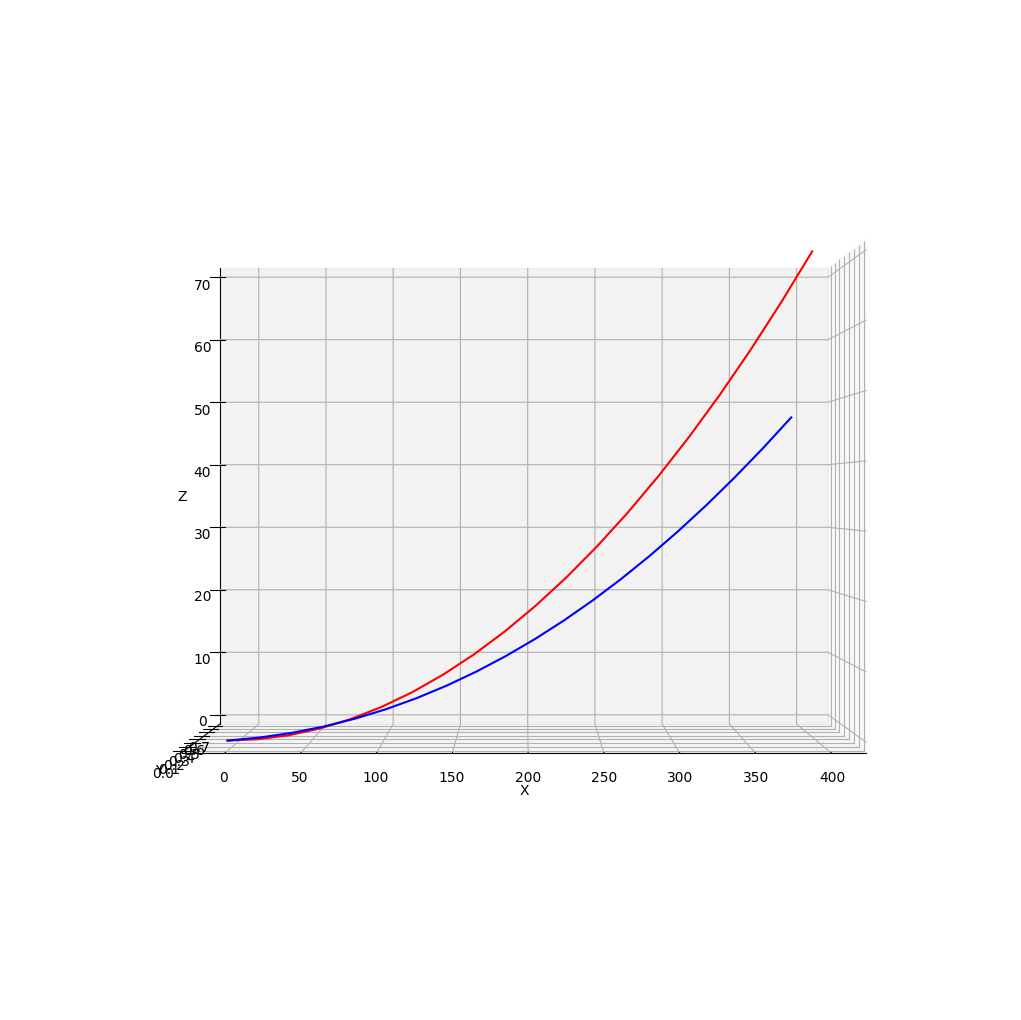

In [109]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [110]:
X,Y,Z

(array([6.30446232e-03, 1.98924869e+01, 4.02813668e+01, 6.08750315e+01,
        8.13915672e+01, 1.01888510e+02, 1.22403331e+02, 1.42957724e+02,
        1.63563712e+02, 1.84227017e+02, 2.04950961e+02, 2.25737928e+02,
        2.46590165e+02, 2.67509745e+02, 2.88499223e+02, 3.09560873e+02,
        3.30697155e+02, 3.51910078e+02, 3.73201506e+02, 3.94572671e+02]),
 array([1.89132686e-05, 5.82391593e-02, 1.15782968e-01, 1.71257500e-01,
        2.23774981e-01, 2.73478873e-01, 3.20605376e-01, 3.65339937e-01,
        4.07720747e-01, 4.47676812e-01, 4.85117014e-01, 5.19995283e-01,
        5.52328663e-01, 5.82165263e-01, 6.09543922e-01, 6.34465404e-01,
        6.56897929e-01, 6.76796324e-01, 6.94120684e-01, 7.08852594e-01]),
 array([-1.51921800e-03,  1.23827406e-01,  5.07261381e-01,  1.15262247e+00,
         2.05714672e+00,  3.22166550e+00,  4.64705587e+00,  6.33396194e+00,
         8.28318896e+00,  1.04960749e+01,  1.29744507e+01,  1.57202287e+01,
         1.87349794e+01,  2.20198609e+01,  2.557

In [111]:
X0,Y0,Z0

(array([  0.        ,  20.47511082,  40.95022165,  61.42533247,
         81.9004433 , 102.37555412, 122.85066495, 143.32577577,
        163.8008866 , 184.27599742, 204.75110824, 225.22621907,
        245.70132989, 266.17644072, 286.65155154, 307.12666237,
        327.60177319, 348.07688401, 368.55199484, 389.02710566]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.19189866,  0.76766204,  1.72749246,  3.07172714,
         4.80083838,  6.9154337 ,  9.41625605, 12.30418411, 15.58023255,
        19.24555239, 23.30143144, 27.74929474, 32.59070503, 37.82736334,
        43.46110957, 49.49392312, 55.92792361, 62.76537163, 70.00866951]))

In [112]:
us=fin.T

In [113]:
us.shape

(240, 481)

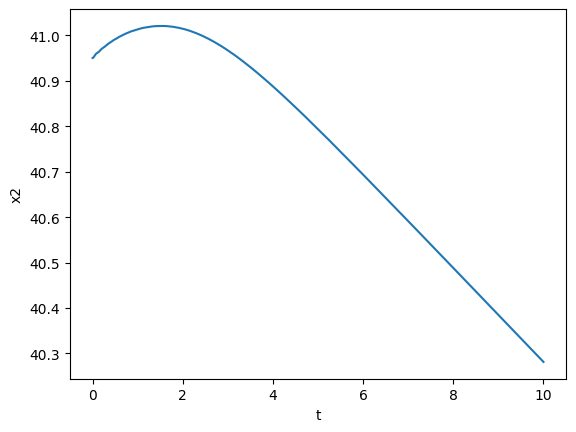

In [114]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

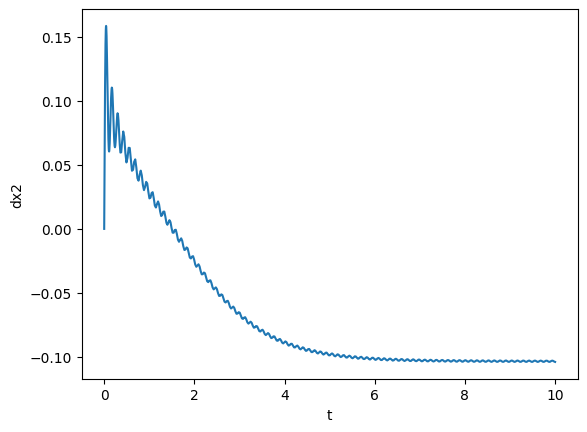

In [115]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

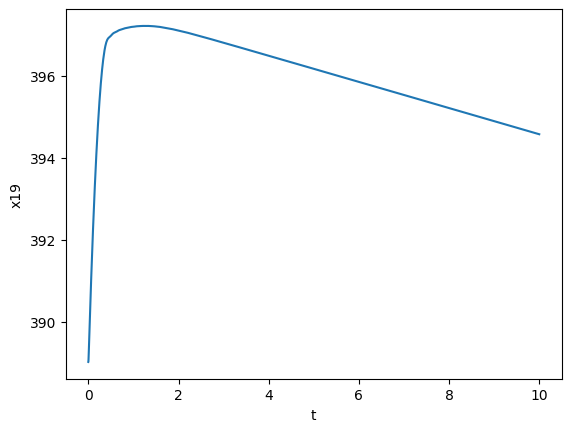

In [116]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

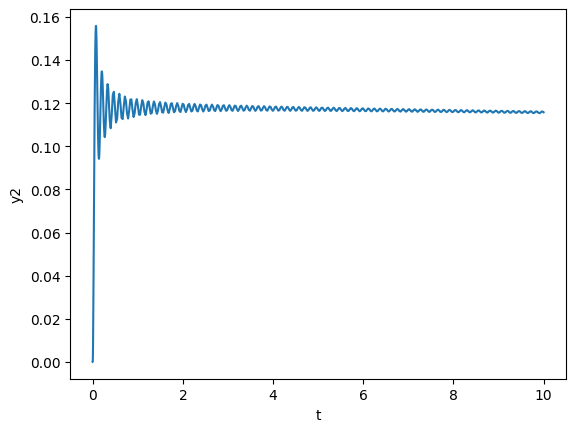

In [117]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

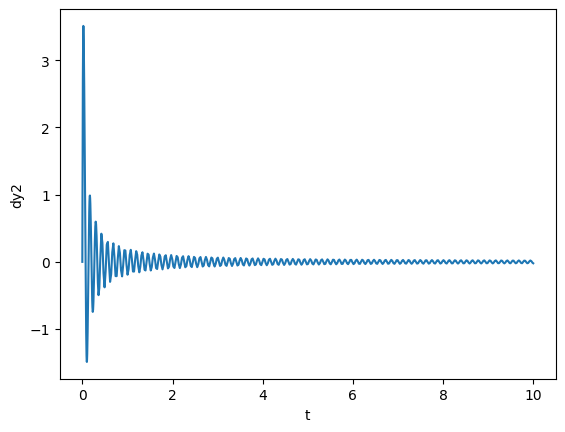

In [118]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

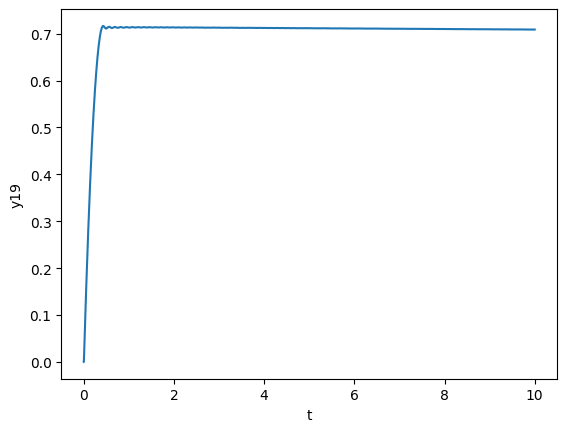

In [119]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

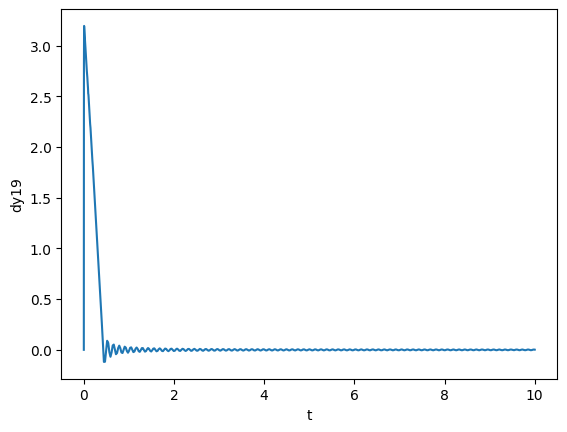

In [120]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

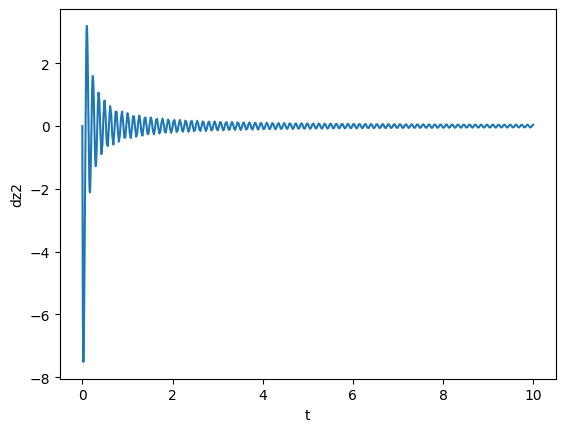

In [121]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

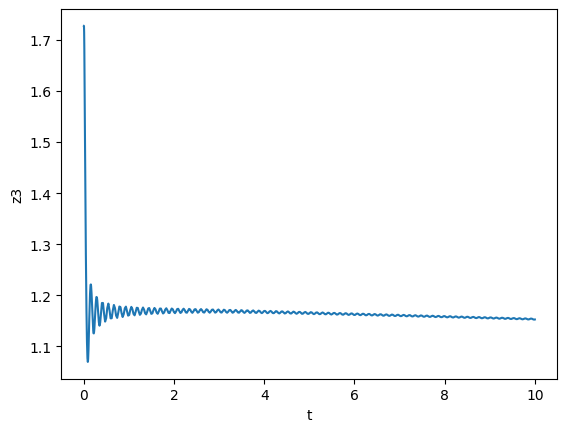

In [122]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

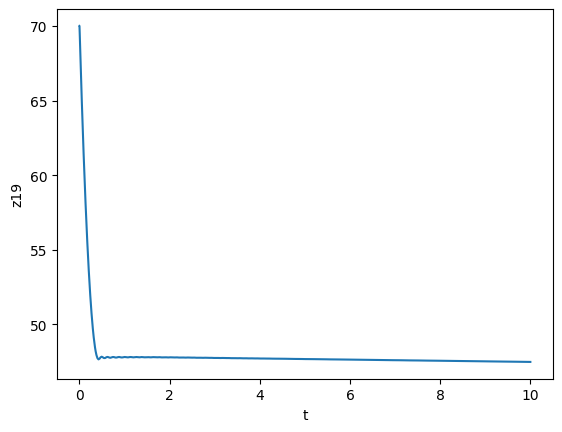

In [123]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

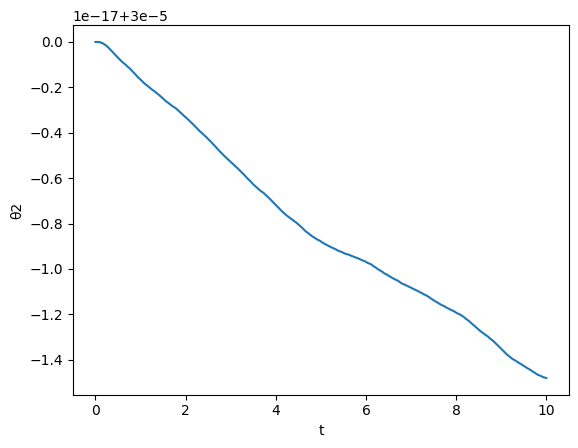

In [124]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

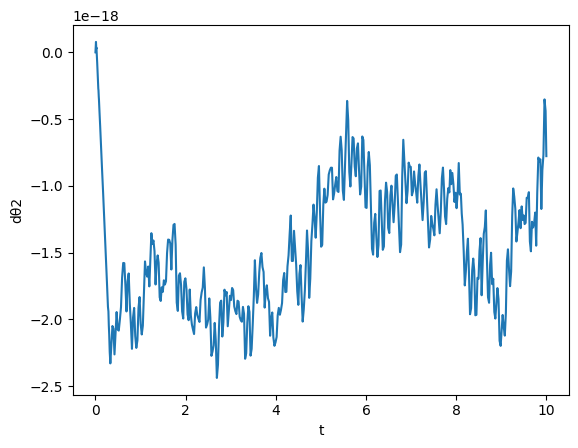

In [125]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

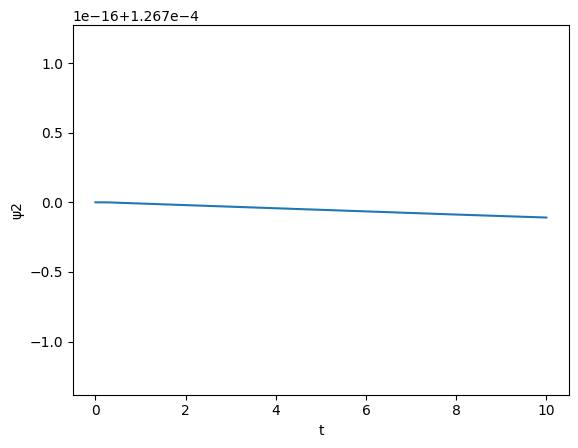

In [126]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

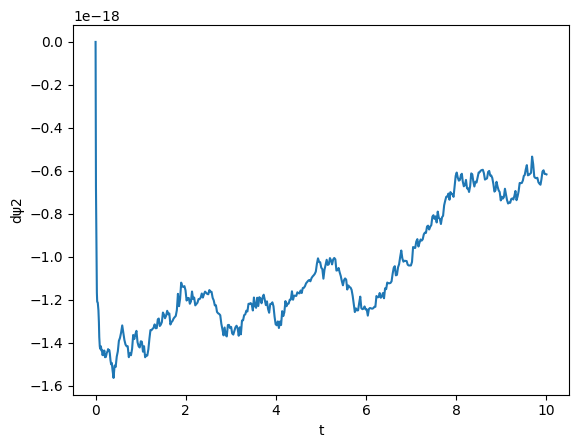

In [127]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

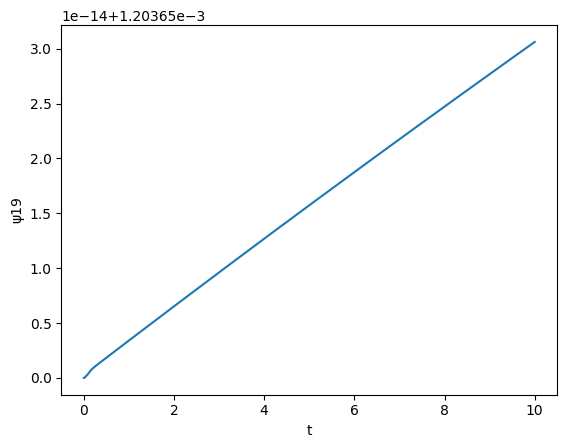

In [128]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [129]:
X010=us.T[:,0*N:1*N]

In [130]:
Y010=us.T[:,2*N:3*N]

In [131]:
Z010=us.T[:,4*N:5*N]

In [132]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()